In [30]:
import pandas as  pd 
import numpy as np

In [31]:
df = pd.read_csv("./goog.csv")

In [32]:
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [33]:
data = df['Close'].values.reshape(-1,1)

In [34]:
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()
data  = scalar.fit_transform(data)

In [35]:
X = []
Y = []

timesteps = 5
for i in range(time_steps, len(data)):
    X.append(data[i-timesteps:i])
    Y.append(data[i])

In [36]:
X = np.array(X)
y = np.array(Y)

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

In [38]:
model = Sequential([
    Input(shape=(X.shape[1], 1)),
    SimpleRNN(50, activation='tanh'),
    Dense(1)
])

In [44]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
history = model.fit(X, y, epochs=50, batch_size=8, verbose=0)

In [45]:
y_pred = model.predict(X)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


In [46]:
y_pred = scalar.inverse_transform(y_pred)
actual = scalar.inverse_transform(y)

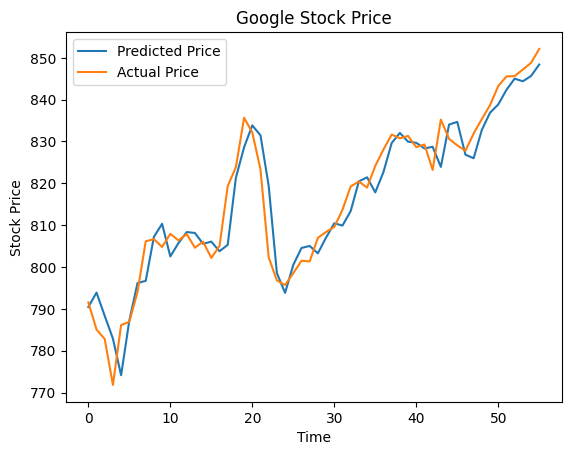

In [47]:
import matplotlib.pyplot as plt
plt.plot(y_pred, label='Predicted Price')
plt.plot(actual, label='Actual Price')
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Google Stock Price")
plt.legend()
plt.show()

In [48]:
from sklearn.metrics import mean_squared_error, r2_score
print(f"MSE: {mean_squared_error(actual, y_pred)}")
print(f"R2 Score: {r2_score(actual, y_pred)}")

MSE: 29.755287009232404
R2 Score: 0.9157319181659167
